### Importing Libraries

In [20]:
#pandas

import pandas as pd


#numpy
import numpy as np
from numpy import set_printoptions


#matplotlib
from matplotlib import pyplot as plt
%matplotlib inline


#seaborn
import seaborn as sns


#sklearn
from sklearn import metrics
from sklearn.linear_model import LogisticRegression  
from sklearn.metrics import classification_report,f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.feature_selection import RFE


import pickle
import warnings
warnings.filterwarnings('ignore')

### Read data from csv

In [21]:
hypothyroid_df  = pd.read_csv('S:\Python\AI LAB\hypothyroid\hypothyroid (1).csv')
# Checking the head of the set
hypothyroid_df.head()

,status,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,thyroid_surgery,query_hypothyroid,query_hyperthyroid,pregnant,...,T3_measured,T3,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG
0,hypothyroid,72,M,f,f,f,f,f,f,f,...,y,0.60,y,15,y,1.48,y,10,n,?
1,hypothyroid,15,F,t,f,f,f,f,f,f,...,y,1.70,y,19,y,1.13,y,17,n,?
2,hypothyroid,24,M,f,f,f,f,f,f,f,...,y,0.20,y,4,y,1,y,0,n,?
3,hypothyroid,24,F,f,f,f,f,f,f,f,...,y,0.40,y,6,y,1.04,y,6,n,?
4,hypothyroid,77,M,f,f,f,f,f,f,f,...,y,1.20,y,57,y,1.28,y,44,n,?


In [22]:
# Checking the tail of the set
hypothyroid_df.tail()

,status,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,thyroid_surgery,query_hypothyroid,query_hyperthyroid,pregnant,...,T3_measured,T3,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG
3158,negative,58,F,f,f,f,f,f,f,f,...,y,1.70,y,86,y,0.91,y,95,n,?
3159,negative,29,F,f,f,f,f,f,f,f,...,y,1.80,y,99,y,1.01,y,98,n,?
3160,negative,77,M,f,f,f,f,f,f,f,...,y,0.60,y,71,y,0.68,y,104,n,?
3161,negative,74,F,f,f,f,f,f,f,f,...,y,0.10,y,65,y,0.48,y,137,n,?
3162,negative,56,F,t,f,f,f,f,f,f,...,y,1.80,y,139,y,0.97,y,143,n,?


In [23]:
# shape of the dataset
hypothyroid_df.shape

(3163, 26)

In [24]:
# size of the dataset
hypothyroid_df.size

82238

In [25]:
# Viewing the statistics of the data
hypothyroid_df.describe()

,status,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,thyroid_surgery,query_hypothyroid,query_hyperthyroid,pregnant,...,T3_measured,T3,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG
count,3163,3163,3163,3163,3163,3163,3163,3163,3163,3163,...,3163,3163,3163,3163,3163,3163,3163,3163,3163,3163
unique,2,93,3,2,2,2,2,2,2,2,...,2,70,2,269,2,159,2,281,2,53
top,negative,?,F,f,f,f,f,f,f,f,...,y,?,y,?,y,?,y,?,n,?
freq,3012,446,2182,2702,3108,3121,3059,2922,2920,3100,...,2468,695,2914,249,2915,248,2916,247,2903,2903


In [26]:
# Checking information of the dataset
hypothyroid_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3163 entries, 0 to 3162
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   status                     3163 non-null   object
 1   age                        3163 non-null   object
 2   sex                        3163 non-null   object
 3   on_thyroxine               3163 non-null   object
 4   query_on_thyroxine         3163 non-null   object
 5   on_antithyroid_medication  3163 non-null   object
 6   thyroid_surgery            3163 non-null   object
 7   query_hypothyroid          3163 non-null   object
 8   query_hyperthyroid         3163 non-null   object
 9   pregnant                   3163 non-null   object
 10  sick                       3163 non-null   object
 11  tumor                      3163 non-null   object
 12  lithium                    3163 non-null   object
 13  goitre                     3163 non-null   object
 14  TSH_meas

In [27]:
# Checking for the data types
hypothyroid_df.dtypes

status                       object
age                          object
sex                          object
on_thyroxine                 object
query_on_thyroxine           object
on_antithyroid_medication    object
thyroid_surgery              object
query_hypothyroid            object
query_hyperthyroid           object
pregnant                     object
sick                         object
tumor                        object
lithium                      object
goitre                       object
TSH_measured                 object
TSH                          object
T3_measured                  object
T3                           object
TT4_measured                 object
TT4                          object
T4U_measured                 object
T4U                          object
FTI_measured                 object
FTI                          object
TBG_measured                 object
TBG                          object
dtype: object

### Data Cleaning

In [28]:
# Checking for unique values in all columns in the dataset
for uni in hypothyroid_df.columns:
#   print(hypothyroid_df.columns)
  print("\t")
  print(hypothyroid_df[uni].unique())


	
['hypothyroid' 'negative']
	
['72' '15' '24' '77' '85' '64' '20' '42' '69' '75' '53' '59' '68' '50'
 '78' '65' '28' '43' '40' '84' '?' '83' '63' '73' '36' '27' '48' '71' '60'
 '34' '79' '62' '74' '32' '41' '70' '29' '5' '58' '35' '51' '22' '16' '44'
 '39' '47' '18' '17' '88' '56' '30' '45' '66' '52' '54' '80' '33' '38'
 '92' '67' '46' '13' '89' '61' '49' '26' '57' '31' '90' '81' '25' '37'
 '76' '87' '23' '55' '86' '98' '21' '97' '1' '6' '14' '82' '11' '19' '9'
 '12' '10' '8' '7' '4' '93']
	
['M' 'F' '?']
	
['f' 't']
	
['f' 't']
	
['f' 't']
	
['f' 't']
	
['f' 't']
	
['f' 't']
	
['f' 't']
	
['f' 't']
	
['f' 't']
	
['f' 't']
	
['f' 't']
	
['y' 'n']
	
['30' '145' '0' '430' '7.30' '138' '7.70' '21' '92' '48' '36' '15' '15.30'
 '25' '61' '28' '170' '54' '216' '56' '71' '46' '70' '34' '53' '9.40'
 '126' '10' '530' '35' '65' '57' '125' '23' '80' '117' '49' '66' '8.20'
 '150' '?' '18' '165' '164' '24' '90' '77' '19' '58' '100' '213' '17'
 '235' '153' '13' '31' '109' '260' '43' '12' '11' '55' 

In [29]:
# replace "?" with NAN 
hypothyroid_df = hypothyroid_df.replace({"?":np.NAN})

In [30]:
# convert object to float
hypothyroid_df[['age','TSH','T3','TT4','T4U','FTI', "TBG"]] = hypothyroid_df[['age','TSH','T3','TT4','T4U','FTI', "TBG"]].astype(float)
hypothyroid_df.dtypes

status                        object
age                          float64
sex                           object
on_thyroxine                  object
query_on_thyroxine            object
on_antithyroid_medication     object
thyroid_surgery               object
query_hypothyroid             object
query_hyperthyroid            object
pregnant                      object
sick                          object
tumor                         object
lithium                       object
goitre                        object
TSH_measured                  object
TSH                          float64
T3_measured                   object
T3                           float64
TT4_measured                  object
TT4                          float64
T4U_measured                  object
T4U                          float64
FTI_measured                  object
FTI                          float64
TBG_measured                  object
TBG                          float64
dtype: object

In [31]:
#handling missing values in the features 
hypothyroid_df.isnull().sum()

status                          0
age                           446
sex                            73
on_thyroxine                    0
query_on_thyroxine              0
on_antithyroid_medication       0
thyroid_surgery                 0
query_hypothyroid               0
query_hyperthyroid              0
pregnant                        0
sick                            0
tumor                           0
lithium                         0
goitre                          0
TSH_measured                    0
TSH                           468
T3_measured                     0
T3                            695
TT4_measured                    0
TT4                           249
T4U_measured                    0
T4U                           248
FTI_measured                    0
FTI                           247
TBG_measured                    0
TBG                          2903
dtype: int64

### Handling missing values

In [32]:
#fill the missing values with the mean
miss_cols = ['FTI','TSH','T3','TT4','T4U', 'TBG']
for i in miss_cols:
    hypothyroid_df[i] = hypothyroid_df[i].fillna(hypothyroid_df[i].mean())
hypothyroid_df

,status,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,thyroid_surgery,query_hypothyroid,query_hyperthyroid,pregnant,...,T3_measured,T3,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG
0,hypothyroid,72.0,M,f,f,f,f,f,f,f,...,y,0.6,y,15.0,y,1.48,y,10.0,n,31.283077
1,hypothyroid,15.0,F,t,f,f,f,f,f,f,...,y,1.7,y,19.0,y,1.13,y,17.0,n,31.283077
2,hypothyroid,24.0,M,f,f,f,f,f,f,f,...,y,0.2,y,4.0,y,1.00,y,0.0,n,31.283077
3,hypothyroid,24.0,F,f,f,f,f,f,f,f,...,y,0.4,y,6.0,y,1.04,y,6.0,n,31.283077
4,hypothyroid,77.0,M,f,f,f,f,f,f,f,...,y,1.2,y,57.0,y,1.28,y,44.0,n,31.283077
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3158,negative,58.0,F,f,f,f,f,f,f,f,...,y,1.7,y,86.0,y,0.91,y,95.0,n,31.283077
3159,negative,29.0,F,f,f,f,f,f,f,f,...,y,1.8,y,99.0,y,1.01,y,98.0,n,31.283077
3160,negative,77.0,M,f,f,f,f,f,f,f,...,y,0.6,y,71.0,y,0.68,y,104.0,n,31.283077
3161,negative,74.0,F,f,f,f,f,f,f,f,...,y,0.1,y,65.0,y,0.48,y,137.0,n,31.283077


In [33]:
#fill age and sex column with mode imputation
hypothyroid_df['age'] = hypothyroid_df['age'].fillna(hypothyroid_df['age'].mode()[0])
hypothyroid_df['sex'] = hypothyroid_df['sex'].fillna(hypothyroid_df['sex'].mode()[0])
hypothyroid_df.isnull().sum()

status                       0
age                          0
sex                          0
on_thyroxine                 0
query_on_thyroxine           0
on_antithyroid_medication    0
thyroid_surgery              0
query_hypothyroid            0
query_hyperthyroid           0
pregnant                     0
sick                         0
tumor                        0
lithium                      0
goitre                       0
TSH_measured                 0
TSH                          0
T3_measured                  0
T3                           0
TT4_measured                 0
TT4                          0
T4U_measured                 0
T4U                          0
FTI_measured                 0
FTI                          0
TBG_measured                 0
TBG                          0
dtype: int64

In [34]:
# feature TBG will be removed because it has over 91% missing values
del hypothyroid_df["TBG"]

In [35]:
#null of each 
hypothyroid_df.isnull().sum()

status                       0
age                          0
sex                          0
on_thyroxine                 0
query_on_thyroxine           0
on_antithyroid_medication    0
thyroid_surgery              0
query_hypothyroid            0
query_hyperthyroid           0
pregnant                     0
sick                         0
tumor                        0
lithium                      0
goitre                       0
TSH_measured                 0
TSH                          0
T3_measured                  0
T3                           0
TT4_measured                 0
TT4                          0
T4U_measured                 0
T4U                          0
FTI_measured                 0
FTI                          0
TBG_measured                 0
dtype: int64

In [36]:
# checking sum of duplicates in the dataset
hypothyroid_df.duplicated().sum()

160

In [37]:
#dropping duplicates
hypothyroid_df = hypothyroid_df.drop_duplicates(keep=False)

In [38]:
#Building heatmap to check correlations
sns.heatmap(round(hypothyroid_df.corr(), 1),annot=True,cmap='viridis')
sns.set(rc={'figure.figsize':(20,20)})
plt.title('Heatmap of co-relation',fontsize=15)
plt.show()

ValueError: could not convert string to float: 'hypothyroid'

In [ ]:
# getting the features with more distinct elements and relation 
hypothyroid_df.nunique()

age                           93
sex                            2
on thyroxine                   2
query on thyroxine             2
on antithyroid medication      2
sick                           2
pregnant                       2
thyroid surgery                2
I131 treatment                 2
query hypothyroid              2
query hyperthyroid             2
lithium                        2
goitre                         2
tumor                          2
hypopituitary                  2
psych                          2
TSH measured                   2
TSH                          288
T3 measured                    2
T3                            70
TT4 measured                   2
TT4                          242
T4U measured                   2
T4U                          147
FTI measured                   2
FTI                          235
TBG measured                   1
referral source                5
binaryClass                    2
dtype: int64

## EDA

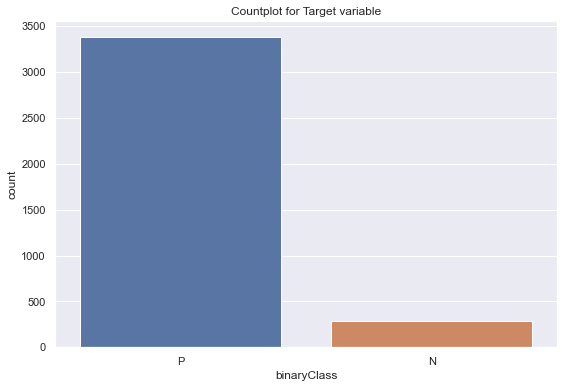

In [ ]:
#displaying the count of target variable
plt.figure(figsize=(9,6))
sns.countplot(x='binaryClass',data=hypothyroid_df)
plt.title("Countplot for Target variable")
plt.show()

Text(0.5, 1.0, 'Distribution of Positive Class Based on Age')

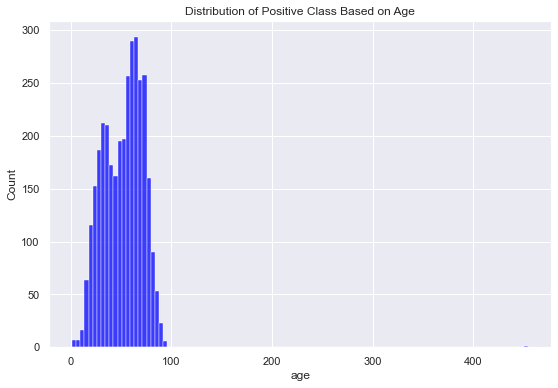

In [ ]:
# distribution of positive class based on age
plt.figure(figsize=(9,6))
positive_thyroid_df = hypothyroid_df[hypothyroid_df.binaryClass == 'P']
sns.histplot(x = 'age',data = positive_thyroid_df, color='blue')
plt.title("Distribution of Positive Class Based on Age")

Text(0.5, 1.0, 'Distribution of negative Class Based on Age')

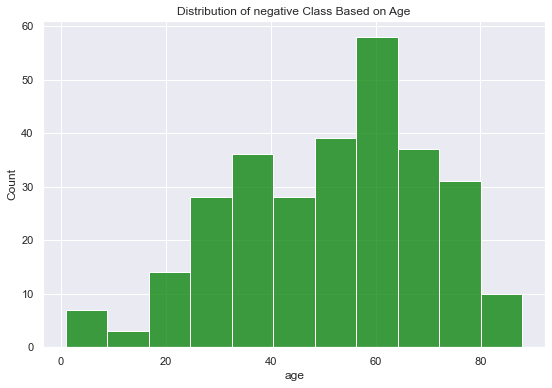

In [ ]:
# distribution of negative class based on age
plt.figure(figsize=(9,6))
negative_thyroid_df = hypothyroid_df[hypothyroid_df.binaryClass == 'N']
sns.histplot(x = 'age',data = negative_thyroid_df, color='green')
plt.title("Distribution of negative Class Based on Age")


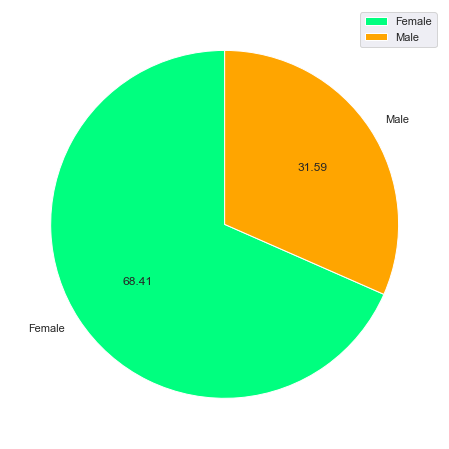

In [ ]:
#Distribution of sex
plt.figure(figsize=(10,8))
plt.pie(x=positive_thyroid_df.sex.value_counts(),
        labels=['Female','Male'],
        startangle = 90,
        colors=['springgreen','orange'],
        autopct='%.2f'
       );
plt.legend()

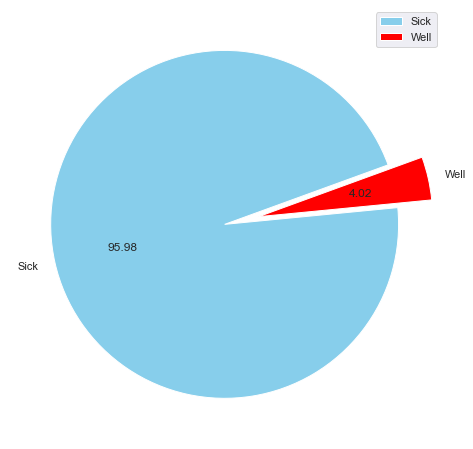

In [ ]:
#distribution of sick against well 
plt.figure(figsize=(8,8))
plt.pie(x=positive_thyroid_df.sick.value_counts(),
        labels=['Sick','Well'],
        startangle = 20,
        colors=['skyblue','red'],
        autopct='%.2f',
        explode=[0,0.2]
       );
plt.legend();

<AxesSubplot:xlabel='T3', ylabel='Density'>

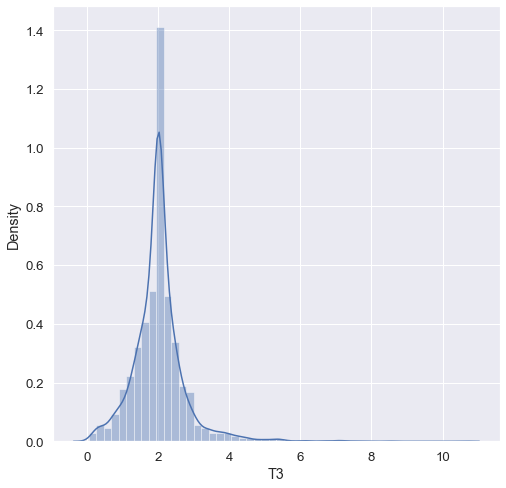

In [ ]:
#distribution of T3
sns.set(rc={'figure.figsize': [8, 8]}, font_scale=1.2)
sns.distplot(hypothyroid_df['T3'])

<AxesSubplot:xlabel='TT4', ylabel='Density'>

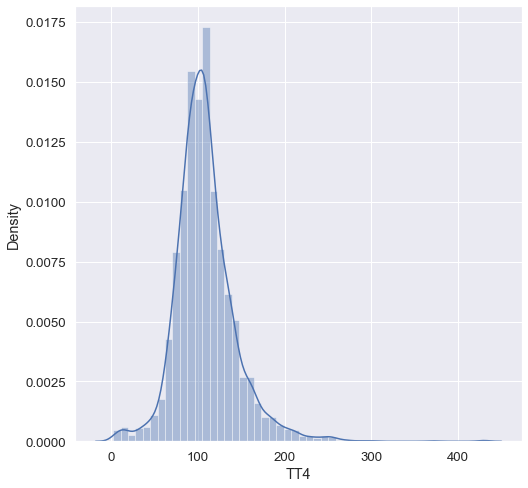

In [ ]:
#distribution of TT4
sns.distplot(hypothyroid_df['TT4'])

<AxesSubplot:xlabel='T4U', ylabel='Density'>

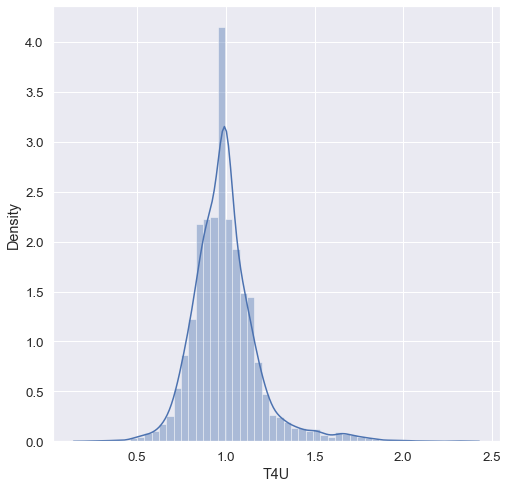

In [ ]:
#distribution of T4U
sns.distplot(hypothyroid_df['T4U'])

<AxesSubplot:xlabel='FTI', ylabel='Density'>

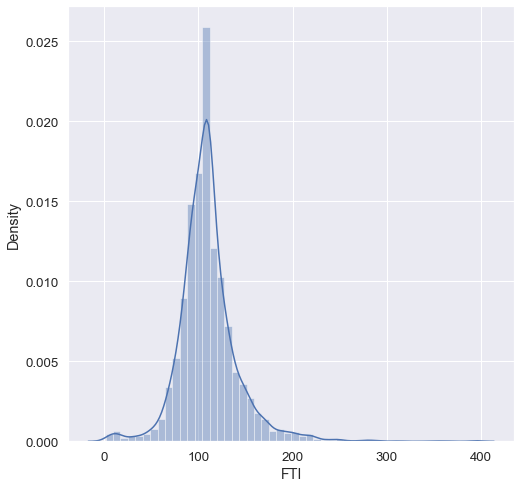

In [ ]:
#distribution of FTI
sns.distplot(hypothyroid_df['FTI'])

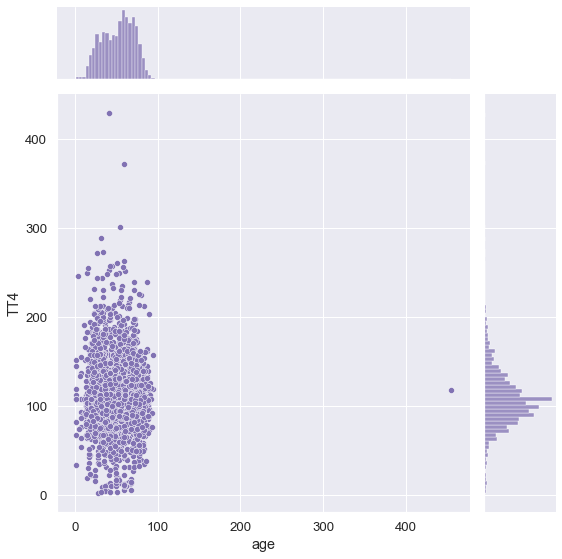

In [ ]:
#two features distribution
sns.jointplot(x='age', y='TT4', data=hypothyroid_df, kind='scatter', height=8, color='m')

<AxesSubplot:xlabel='binaryClass', ylabel='count'>

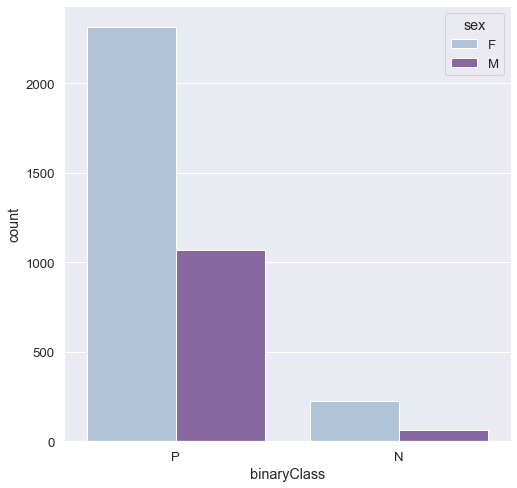

In [ ]:
#dependent variable distribution by sex
sns.countplot(x='binaryClass', data=hypothyroid_df, hue='sex', palette='BuPu')

In [ ]:
#feature correlation
hypothyroid_df_corr = hypothyroid_df.corr()
hypothyroid_df_corr

,age,TSH,T3,TT4,T4U,FTI
age,1.000000,-0.056858,-0.217095,-0.038723,-0.158990,0.049647
TSH,-0.056858,1.000000,-0.147334,-0.261439,0.071045,-0.293234
T3,-0.217095,-0.147334,1.000000,0.509175,0.407247,0.308943
TT4,-0.038723,-0.261439,0.509175,1.000000,0.426681,0.778983
T4U,-0.158990,0.071045,0.407247,0.426681,1.000000,-0.173953
FTI,0.049647,-0.293234,0.308943,0.778983,-0.173953,1.000000


In [ ]:
# 'referral source' into indicator columns of 0s and 1s (dummies)
hypothyroid_df = pd.get_dummies(hypothyroid_df, columns=['referral source'])

### Transform non-numerical labels to numerical labels.

In [ ]:
#convert target variable to numeric
hypothyroid_df["binaryClass"] = hypothyroid_df["binaryClass"].replace({"P":1,"N":0})

In [ ]:
#extracting independent variable
X = hypothyroid_df.drop('binaryClass',axis=1)

In [ ]:
#extracting dependent variable
y = hypothyroid_df.binaryClass

In [ ]:
#encoding the independent variable 
numerical_features = list()
categorical_features = list()
for column in X.columns:
    # In the dataset we only have float and int64.
    if (hypothyroid_df[column].dtype == 'float64' or hypothyroid_df[column].dtype == 'int64'):
        numerical_features.append(column)
    # Categorical
    elif (hypothyroid_df[column].dtype == 'object' or hypothyroid_df[column].dtype == 'bool'):
        categorical_features.append(column)
        
print('There are a total of {} numerical features in the dataset.'.format(len(numerical_features)))
print('There are a total of {} categorical features in the dataset.'.format(len(categorical_features)))

There are a total of 6 numerical features in the dataset.
There are a total of 21 categorical features in the dataset.


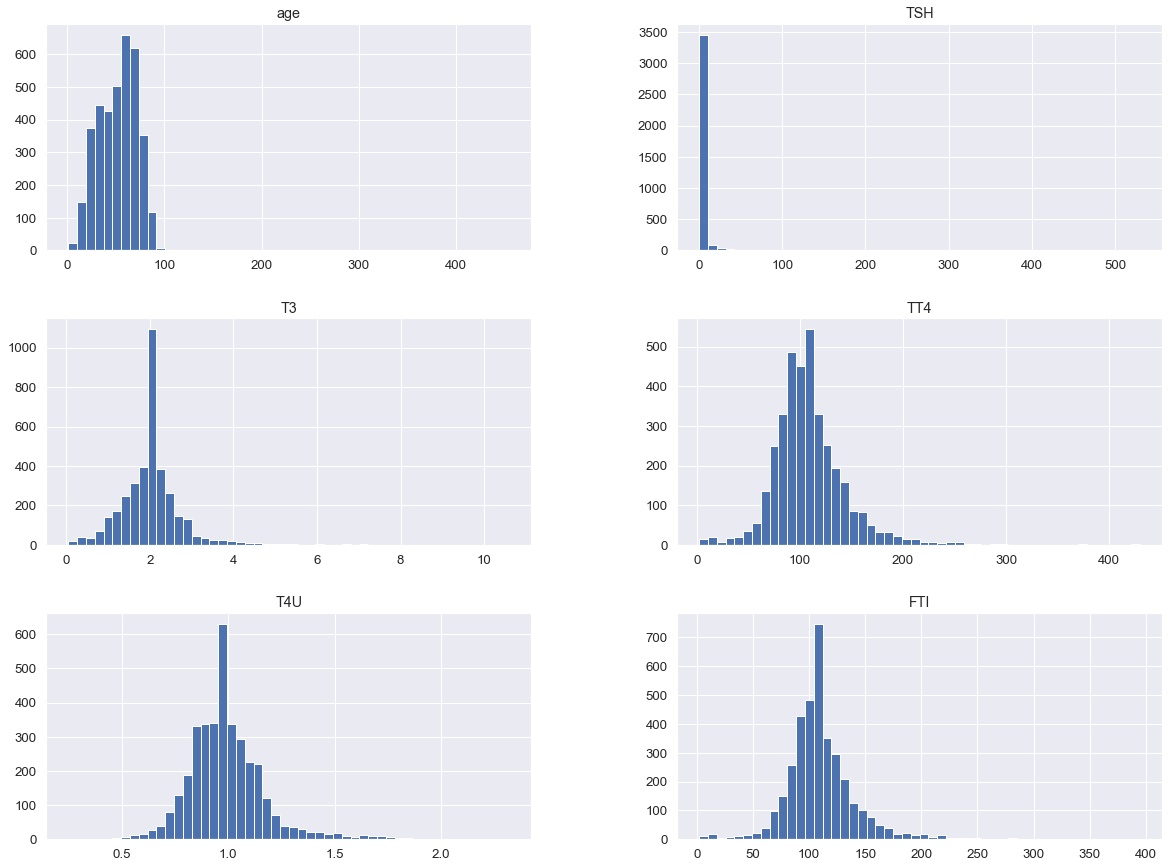

In [ ]:
#visualization of numerical features
X_num_total = X[numerical_features]
X_num_total.hist(bins=50,figsize=(20, 15))
plt.show()

In [ ]:
# categorical feature list
categorical_features_index = list()
# Encode categorical features, get the indexes of categorical 
for p in categorical_features:
    categorical_features_index.append(X.columns.get_loc(p))
    X[p] = LabelEncoder().fit_transform(X[p])

In [ ]:
#encoding the dependent variable
labelencoder_y = LabelEncoder()  
y = labelencoder_y.fit_transform(y)

### Split original data into training data and testing data

In [ ]:
#splitting the data set with an 80% training and 20% testing
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.2, random_state=11)  
len(X_train), len(X_test)

(2940, 735)

### Feature scaling or normalization

In [ ]:
#standardize the independent variables of the dataset 
st_X= StandardScaler()  
X_train= st_X.fit_transform(X_train) 
len(X_train), len(y_train)

(2940, 2940)

In [ ]:
#transforming the independent variable test
X_test= st_X.transform(X_test) 

## MODEL

### LOGISTIC REGRESSION 

In [ ]:
# Fitting Logistic Regression to the Training set
classifier= LogisticRegression(random_state=11) 
#training the model using training set
classifier.fit(X_train, y_train)  

LogisticRegression(random_state=11)

In [ ]:
# Predicting and training the Test Result
classifier_predict_train = classifier.predict(X_train)
classifier_predict_test= classifier.predict(X_test) 

In [ ]:
# checking the accuracy score of the test and train set
print('Prediction on training set', accuracy_score(classifier_predict_train, y_train))
print('Prediction on testing set', accuracy_score(classifier_predict_test, y_test))

Prediction on training set 0.9649659863945578
Prediction on testing set 0.964625850340136


## Feature Selection

### Feature Importance

In [ ]:
#selecting the important feature
FeatureImportance = classifier.coef_[0]
for i,d in enumerate (FeatureImportance):
    print('Feature: %0d, Score: %5f'%(i,d))

Feature: 0, Score: 0.067659
Feature: 1, Score: 0.136849
Feature: 2, Score: 2.779527
Feature: 3, Score: 0.034048
Feature: 4, Score: 0.035618
Feature: 5, Score: -0.001353
Feature: 6, Score: 0.327284
Feature: 7, Score: 2.750372
Feature: 8, Score: 0.000301
Feature: 9, Score: -0.175957
Feature: 10, Score: -0.013400
Feature: 11, Score: -0.043275
Feature: 12, Score: 0.357834
Feature: 13, Score: -0.112193
Feature: 14, Score: 0.077981
Feature: 15, Score: -0.036835
Feature: 16, Score: -1.085174
Feature: 17, Score: -6.775846
Feature: 18, Score: 0.128017
Feature: 19, Score: 0.396733
Feature: 20, Score: -0.393356
Feature: 21, Score: 0.489445
Feature: 22, Score: 0.038419
Feature: 23, Score: -0.217978
Feature: 24, Score: 0.059218
Feature: 25, Score: 0.523084
Feature: 26, Score: 0.000000
Feature: 27, Score: 0.128380
Feature: 28, Score: 0.164534
Feature: 29, Score: -0.067721
Feature: 30, Score: -0.052756
Feature: 31, Score: -0.085638


Text(0.5, 1.0, 'Barchart showing the feature importance for Logistics Regression Model')

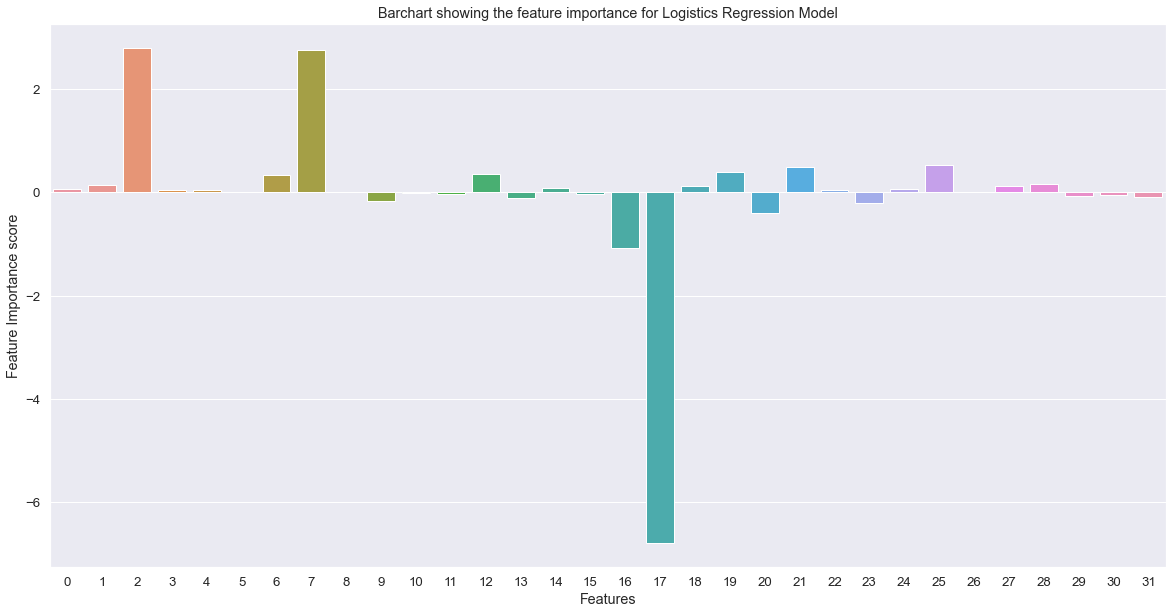

In [ ]:
#chart to visualize the feature importance
plt.subplots(figsize=(20,10))
sns.barplot([X for X in range(len(FeatureImportance))], FeatureImportance)
plt.xlabel('Features')
plt.ylabel('Feature Importance score')
plt.title('Barchart showing the feature importance for Logistics Regression Model')

### Feature Selection

In [ ]:
#using the new cols with the selected feature
cols = ['age', 'sex', 'on thyroxine', 'query on thyroxine',
       'on antithyroid medication','pregnant', 'thyroid surgery', 'query hypothyroid', 'query hyperthyroid',
       'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH measured', 'TSH',
       'T3 measured', 'T3', 'TT4 measured', 'TT4', 'T4U',
       'FTI measured', 'FTI','referral source_STMW', 'referral source_SVHC', 'referral source_SVHD',
       'referral source_SVI', 'referral source_other']

X_new= X[cols]
y_new= y

In [ ]:
#encoding the new independent variable
X_new = X_new.apply(LabelEncoder().fit_transform)
X_new_array = X_new.to_numpy()

In [ ]:
#encoding the new dependent variable
Labelencoder_y_new= LabelEncoder()  
y_new = Labelencoder_y_new.fit_transform(y)

In [ ]:
#splitting the dataset 80-20%
X_new_train, X_new_test, y_new_train, y_new_test = train_test_split( X_new_array, y_new, test_size=0.2, random_state=11)
X_new_train.shape

(2940, 27)

In [ ]:
#standardize the independent variables of the dataset
st_X= StandardScaler()  
X_LR_train= st_X.fit_transform(X_new_train) 
X_LR_test = st_X.fit_transform(X_new_test)
len(X_new_train), len(y_new_train)

(2940, 2940)

In [ ]:
#refitting logistic regression
final_classifier = LogisticRegression(random_state=11) 
#training the model using training set
final_classifier.fit(X_LR_train, y_new_train) 

LogisticRegression(random_state=11)

In [ ]:
# Predicting and training the Test Result
final_classifier_predict_train = final_classifier.predict(X_LR_train)
final_classifier_predict_test= final_classifier.predict(X_LR_test)

In [ ]:
# checking the accuracy score of the test and train set
print('Prediction on training set', accuracy_score(final_classifier_predict_train, y_new_train))
print('Prediction on testing set', accuracy_score(final_classifier_predict_test, y_new_test))

Prediction on training set 0.9846938775510204
Prediction on testing set 0.9891156462585035


### Confusion Matrix

In [ ]:
# Creating the confusion matrix
def get_matrix(name, y_mat_test, mat_classifier_predict_test):
    conf_matrix = metrics.confusion_matrix(y_mat_test, mat_classifier_predict_test)
    
    # Assigning columns names

    # Showing the confusion matrix
    # save confusion matrix and slice into four pieces

    TP = conf_matrix[1][1]
    TN = conf_matrix[0][0]
    FP = conf_matrix[0][1]
    FN = conf_matrix[1][0]
    print('True Positives:', TP)
    print('True Negatives:', TN)
    print('False Positives:', FP)
    print('False Negatives:', FN)

    # calculate accuracy
    conf_accuracy = (float (TP+TN) / float(TP + TN + FP + FN))

    # calculate mis-classification
    conf_misclassification = 1- conf_accuracy

    # calculate the recall
    conf_recall = (TP / float(TP + FN))

    # calculate the True Negative Rate
    conf_True_Negative_Rate = (TN / float(TN + FP))

    # calculate precision
    conf_precision = (TN / float(TN + FP))

    # calculate f_1 score
    conf_f1 = 2 * ((conf_precision * conf_recall) / (conf_precision + conf_recall))

    print('-'*50)
    print(f'Accuracy: {round(conf_accuracy,4)}') 
    print(f'Mis-Classification: {round(conf_misclassification,2)}') 
    print(f'Sensitivity: {round(conf_recall,2)}') 
    print(f'Specificity: {round(conf_True_Negative_Rate,2)}') 
    print(f'Precision: {round(conf_precision,2)}')
    print(f'f_1 Score: {round(conf_f1,2)}')
    print('-'*50)
    print(name + ' confusion matrix is:')
    print(conf_matrix)

In [ ]:
#conf matrix
get_matrix('feature importance', y_new_test, final_classifier_predict_test)

True Positives: 677
True Negatives: 50
False Positives: 7
False Negatives: 1
--------------------------------------------------
Accuracy: 0.9891
Mis-Classification: 0.01
Sensitivity: 1.0
Specificity: 0.88
Precision: 0.88
f_1 Score: 0.93
--------------------------------------------------
feature importance confusion matrix is:
[[ 50   7]
 [  1 677]]


### Univarate feature selection

In [ ]:
#fitting univarate feature selection on the dataset
test = SelectKBest(score_func=f_classif, k=7)
fit = test.fit(X_train, y_train)
X_train_fit = fit.transform(X_train)
X_test_fit = fit.transform(X_test)

X_train_fit.shape

(2940, 7)

Feature 0: 0.006287
Feature 1: 9.245346
Feature 2: 19.633047
Feature 3: 1.890490
Feature 4: 1.031709
Feature 5: 0.164140
Feature 6: 3.686680
Feature 7: 1.729407
Feature 8: 0.289018
Feature 9: 29.467948
Feature 10: 0.818815
Feature 11: 0.012788
Feature 12: 2.709931
Feature 13: 0.070160
Feature 14: 0.086448
Feature 15: 5.473782
Feature 16: 20.898817
Feature 17: 681.951792
Feature 18: 1.573382
Feature 19: 103.818778
Feature 20: 6.065907
Feature 21: 278.808888
Feature 22: 0.006030
Feature 23: 1.477757
Feature 24: 0.003315
Feature 25: 320.785576
Feature 26: nan
Feature 27: 0.556259
Feature 28: 13.214054
Feature 29: 0.126184
Feature 30: 5.416318
Feature 31: 0.128384


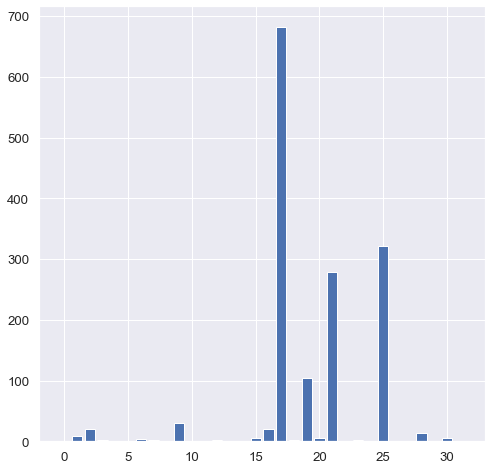

In [ ]:
#univarate feature selection
for i in range(len(fit.scores_)):
    print('Feature %d: %f' % (i, fit.scores_[i]))
plt.bar([i for i in range(len(fit.scores_))], fit.scores_)    
plt.show()

In [ ]:
classifier= LogisticRegression(random_state=11) 
#training the model using training set
classifier.fit(X_train_fit, y_train)  

LogisticRegression(random_state=11)

In [ ]:
# Predicting and training the Test Result
classifier_predict_train_Uni = classifier.predict(X_train_fit)
classifier_predict_test_Uni= classifier.predict(X_test_fit) 

In [ ]:
# checking the accuracy score of the test and train set
print('Prediction on training set', accuracy_score(classifier_predict_train_Uni, y_train))
print('Prediction on testing set', accuracy_score(classifier_predict_test_Uni, y_test))

Prediction on training set 0.9598639455782313
Prediction on testing set 0.9564625850340136


In [ ]:
#conf_matrix on univarate
get_matrix('univarate', y_test, classifier_predict_test_Uni)

True Positives: 676
True Negatives: 27
False Positives: 30
False Negatives: 2
--------------------------------------------------
Accuracy: 0.9565
Mis-Classification: 0.04
Sensitivity: 1.0
Specificity: 0.47
Precision: 0.47
f_1 Score: 0.64
--------------------------------------------------
univarate confusion matrix is:
[[ 27  30]
 [  2 676]]


### Recursive feature elimination

In [ ]:
#RFE on logisitic regression
from sklearn.feature_selection import RFE
classifier = LogisticRegression(solver='lbfgs')
rfe = RFE(classifier)
fit = rfe.fit(X_train,y_train)
X_train_fit_RFE = fit.transform(X_train)
X_test_fit_RFE = fit.transform(X_test)
X_train_fit_RFE.shape

(2940, 16)

Num Features: 16
Selected Features: [False  True  True False False False  True  True False  True False False
  True False False False  True  True  True  True  True  True False  True
 False  True False  True  True False False False]
Feature Ranking: [ 5  1  1 13 12 15  1  1 16  1 14  9  1  2  4 11  1  1  1  1  1  1 10  1
  3  1 17  1  1  6  8  7]
Feature 0: 5.000000
Feature 1: 1.000000
Feature 2: 1.000000
Feature 3: 13.000000
Feature 4: 12.000000
Feature 5: 15.000000
Feature 6: 1.000000
Feature 7: 1.000000
Feature 8: 16.000000
Feature 9: 1.000000
Feature 10: 14.000000
Feature 11: 9.000000
Feature 12: 1.000000
Feature 13: 2.000000
Feature 14: 4.000000
Feature 15: 11.000000
Feature 16: 1.000000
Feature 17: 1.000000
Feature 18: 1.000000
Feature 19: 1.000000
Feature 20: 1.000000
Feature 21: 1.000000
Feature 22: 10.000000
Feature 23: 1.000000
Feature 24: 3.000000
Feature 25: 1.000000
Feature 26: 17.000000
Feature 27: 1.000000
Feature 28: 1.000000
Feature 29: 6.000000
Feature 30: 8.000000
Fea

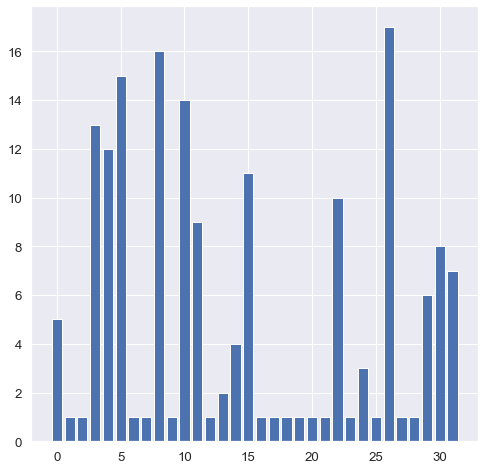

In [ ]:
#num of features
print("Num Features: %d" % fit.n_features_)
print("Selected Features: %s" % fit.support_)
print("Feature Ranking: %s" % fit.ranking_)
for i in range(len(fit.support_)):
    print('Feature %d: %f' % (i, fit.ranking_[i]))
plt.bar([i for i in range(len(fit.ranking_))], fit.ranking_)
    
plt.show()

In [ ]:
classifier= LogisticRegression(random_state=11) 
#training the model using training set
classifier.fit(X_train_fit_RFE, y_train)  

LogisticRegression(random_state=11)

In [ ]:
# Predicting and training the Test Result
classifier_predict_train_RFE = classifier.predict(X_train_fit_RFE)
classifier_predict_test_RFE = classifier.predict(X_test_fit_RFE)

In [ ]:
from sklearn.metrics import accuracy_score
# checking the accuracy score of the test and train set
print('Prediction on training set', accuracy_score(classifier_predict_train_RFE, y_train))
print('Prediction on testing set', accuracy_score(classifier_predict_test_RFE, y_test))

Prediction on training set 0.9649659863945578
Prediction on testing set 0.9619047619047619


In [ ]:
#conf_matrix on RFE
get_matrix('recursive', y_test, classifier_predict_test_RFE)

True Positives: 677
True Negatives: 30
False Positives: 27
False Negatives: 1
--------------------------------------------------
Accuracy: 0.9619
Mis-Classification: 0.04
Sensitivity: 1.0
Specificity: 0.53
Precision: 0.53
f_1 Score: 0.69
--------------------------------------------------
recursive confusion matrix is:
[[ 30  27]
 [  1 677]]
